In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from utils import *
import time


# -----------------------------
# global setup
# -----------------------------
seed = 43
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

def sync_timer():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

rng = np.random.default_rng(seed)

excel_path = "rssi_cl.xlsx"

L = 50
M = 5
sigma = 10.0
seq_len = 15
B = 100
local_epochs = 5
drift_round = 25
warmup_rounds = 20

fault_round = drift_round
fault_weight_shift = 5.0
fault_bias_shift = 2.5

tau_det = 2
guard_hops = 1
first_alarm_hop_radius = 1

rssi_info = load_rssi_excel_data(
    excel_path=excel_path,
    data_start_row=2,
    normalize=True,
)

N = rssi_info["N"]
R = rssi_info["min_len"] // B
r_max = L / 5

print(f"N = {N}")
print(f"min series length = {rssi_info['min_len']}")
print(f"B = {B}")
print(f"R = {R}")
print(f"samples per node per round = {B - seq_len - 1}")

positions = generate_sensor_positions(
    n=N,
    L=L,
    seed=seed,
    margin_frac=0.05,
    min_dist=5.0,
)

dist_matrix = compute_distance_matrix(positions)

W = build_uniform_neighbor_matrix(
    positions,
    r_max=r_max,
    self_weight=0.05,
)

A_graph = adjacency_from_mixing_matrix(W)
hop_dist = all_pairs_hop_distances(A_graph)

neighbor_counts = A_graph.sum(axis=1)
print(
    "min/mean/max graph degree:",
    int(neighbor_counts.min()),
    float(neighbor_counts.mean()),
    int(neighbor_counts.max()),
)

sentinel_idx = np.array(
    select_sentinels(
        positions,
        min(M, N - 1),
        seed=seed,
        first="centroid",
    ),
    dtype=int,
)

hidden_idx = np.setdiff1d(np.arange(N), sentinel_idx)
if len(hidden_idx) == 0:
    raise RuntimeError("No hidden node left for source_node. Reduce M.")

source_node = int(rng.choice(hidden_idx))

print("sentinel nodes:", sentinel_idx)
print("true hidden source:", source_node)


def make_fresh_system(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    models = initialize_models(
        N=N,
        input_dim=1,
        hidden_dim=32,
        layer_dim=1,
        output_dim=1,
    )

    optimizers = [
        torch.optim.Adam(m.parameters(), lr=0.001)
        for m in models
    ]

    online_gen = ExcelBlockDataGenerator(
        excel_path=excel_path,
        seq_len=seq_len,
        block_size=B,
        data_start_row=2,
    )

    return models, optimizers, online_gen


# --------------------------------------------------
# main runner
# --------------------------------------------------
def run_simulation(enable_intervention=True, seed=42):
    models, optimizers, online_gen = make_fresh_system(seed)

    ResidualMSE = np.full((R, N), np.nan, dtype=float)
    NetworkMSE = np.full(R, np.nan, dtype=float)

    RoundDuration = np.full(R, np.nan, dtype=float)   # full round time
    CommDuration = np.full(R, np.nan, dtype=float)    # communication-only time

    # -------- detector state --------
    Alarms = np.zeros((R, N), dtype=np.int8)
    BaselineEnergy = np.zeros(N, dtype=float)
    rho = 0.05

    already_drifted_sentinel_set = set()
    SentinelMaxDT = {int(s): -np.inf for s in sentinel_idx}

    def detector_factory():
        return MeanShiftCUSUMDetector(k=0.2, h=3.5)

    sentinel_detectors = {
        int(s): detector_factory()
        for s in sentinel_idx
    }
    sentinel_warmup_mse = {
        int(s): []
        for s in sentinel_idx
    }

    # -------- intervention / spread state --------
    W_base = W.copy()
    W_current = W_base.copy()

    alarm_times = {int(s): None for s in sentinel_idx}

    infected_now = set()
    ever_infected = set()
    quarantined_now = set()
    disabled_nodes = set()
    suspected_source = None
    localization_round = None
    estimated_source_trace = np.full(R, np.nan)
    intervention_round = None   
    fault_round_local = drift_round
    fault_weight_shift_local = fault_weight_shift
    fault_bias_shift_local = fault_bias_shift
    fault_anchor_by_node = {}

    for r in range(R):
        
        t_round_start = sync_timer()
        if r == fault_round_local:
            infected_now.add(int(source_node))
            ever_infected.add(int(source_node))

        X_round, y_round, _ = online_gen.generate_round(return_states=True)

        round_residuals_pre = {}

        # ------------------------------------------
        # PASS 1: pre-training residuals
        # ------------------------------------------
        for i in range(N):
            x_batch = X_round[i]
            y_batch = y_round[i]
            model = models[i]

            model.eval()
            with torch.no_grad():
                x_tensor = torch.tensor(
                    x_batch, dtype=torch.float32
                ).unsqueeze(-1).to(device)
                preds_pre = model(x_tensor).squeeze().detach().cpu().numpy()

            residual_pre = y_batch - preds_pre
            round_residuals_pre[i] = residual_pre.copy()
            ResidualMSE[r, i] = float(np.mean(residual_pre ** 2))

        t_comm_start = sync_timer()
        # ------------------------------------------
        # PASS 2: detection + intervention
        # ------------------------------------------
        if enable_intervention:
            for s in sentinel_idx:
                s = int(s)

                if s in already_drifted_sentinel_set:
                    Alarms[r, s] = 1
                    continue

                batch_mse = float(ResidualMSE[r, s])

                if r < warmup_rounds:
                    sentinel_warmup_mse[s].append(batch_mse)
                    Alarms[r, s] = 0
                else:
                    det = sentinel_detectors[s]

                    if r == warmup_rounds:
                        det.fit(sentinel_warmup_mse[s])

                    hit = det.update(batch_mse, round_idx=r)

                    if det.stat_trace:
                        SentinelMaxDT[s] = max(SentinelMaxDT[s], det.stat_trace[-1])

                    if hit is not None:
                        Alarms[r, s] = 1
                        already_drifted_sentinel_set.add(s)
                        if alarm_times[s] is None:
                            alarm_times[s] = r
                    else:
                        Alarms[r, s] = 0
                        BaselineEnergy[s] = (1.0 - rho) * BaselineEnergy[s] + rho * batch_mse

            num_alarms = sum(t is not None for t in alarm_times.values())
            est = None

            if suspected_source is not None:
                disabled_nodes = {int(suspected_source)}
            else:
                disabled_nodes = set()

            if num_alarms >= 2:
                candidate_nodes = np.setdiff1d(np.arange(N), sentinel_idx)

                est = estimate_source_and_region(
                    alarm_times=alarm_times,
                    sentinel_idx=sentinel_idx,
                    hop_dist=hop_dist,
                    current_round=r,
                    tau_det=tau_det,
                    guard_hops=guard_hops,
                    min_required_alarms=2,
                    candidate_nodes=candidate_nodes,
                )

            if est is not None:
                if intervention_round is None:
                    intervention_round = r   

                quarantined_now = set()

                new_source_hat = int(est["source_hat"])
                affected_hat = set(est["affected_hat"])
                estimated_source_trace[r] = new_source_hat

                reintroduce_nodes = set()
                if suspected_source is not None and suspected_source != new_source_hat:
                    reintroduce_nodes.add(int(suspected_source))

                suspected_source = new_source_hat
                disabled_nodes = {suspected_source}
                if localization_round is None and r >= fault_round_local and suspected_source == source_node:
                    localization_round = r

                heal_set = (affected_hat - disabled_nodes) | reintroduce_nodes

                healthy_pool = set(range(N)) - affected_hat - disabled_nodes
                if len(healthy_pool) == 0:
                    healthy_pool = set(range(N)) - disabled_nodes

                heal_nodes_from_healthy_pool(
                    models=models,
                    W_base=W_base,
                    nodes_to_heal=heal_set,
                    healthy_pool=healthy_pool,
                    optimizers=optimizers,
                )

                infected_now -= heal_set

                for j in heal_set:
                    fault_anchor_by_node.pop(int(j), None)

                W_current = build_disabled_matrix(W_base, disabled_nodes)

            elif num_alarms >= 1 and suspected_source is None:
                if intervention_round is None:
                    intervention_round = r   

                
                earliest_s = min(
                    [s for s in alarm_times if alarm_times[s] is not None],
                    key=lambda s: alarm_times[s]
                )

                quarantined_now = hop_ball(
                    A_graph,
                    center=earliest_s,
                    radius=first_alarm_hop_radius
                )
                disabled_nodes = set()
                W_current = build_quarantine_matrix(W_base, quarantined_now)

            else:
                quarantined_now = set()
                if suspected_source is not None:
                    W_current = build_disabled_matrix(W_base, disabled_nodes)
                else:
                    W_current = W_base.copy()

        else:
            quarantined_now = set()
            disabled_nodes = set()
            suspected_source = None
            W_current = W_base.copy()

        active_nodes = sorted(set(range(N)) - set(disabled_nodes) - set(quarantined_now))
        if len(active_nodes) > 0:
            NetworkMSE[r] = float(np.nanmean(ResidualMSE[r, active_nodes]))
        else:
            NetworkMSE[r] = np.nan

        # ------------------------------------------
        # PASS 3: local training
        # ------------------------------------------
        for i in range(N):
            if i in disabled_nodes:
                continue

            x_batch = X_round[i]
            y_batch = y_round[i]

            for _ in range(local_epochs):
                local_update(models[i], optimizers[i], x_batch, y_batch)

        # ------------------------------------------
        # PASS 3.5: true fault injection
        # ------------------------------------------
        for j in sorted(infected_now - disabled_nodes - quarantined_now):
            if j not in fault_anchor_by_node:
                fault_anchor_by_node[j] = snapshot_output_layer(models[j])

            apply_persistent_output_fault(
                models[j],
                anchor=fault_anchor_by_node[j],
                delta_weight=fault_weight_shift_local,
                delta_bias=fault_bias_shift_local,
                mode="all",
            )

        # ------------------------------------------
        # PASS 4: gossip
        # ------------------------------------------
        gossip_step(models, W_current)
        t_comm_end = sync_timer()
        CommDuration[r] = t_comm_end - t_comm_start

        # ------------------------------------------
        # PASS 5: true spread
        # ------------------------------------------
        blocked_nodes = set(disabled_nodes) | set(quarantined_now)

        infected_now = spread_one_hop(
            A_graph,
            infected_nodes=infected_now,
            quarantined_nodes=blocked_nodes,
        )

        if enable_intervention and suspected_source is not None and suspected_source == source_node:
            infected_now.discard(int(source_node))

        ever_infected |= infected_now

        t_round_end = sync_timer()
        RoundDuration[r] = t_round_end - t_round_start


    return NetworkMSE, localization_round, estimated_source_trace, intervention_round, RoundDuration, CommDuration


# -----------------------------
# run comparison
# -----------------------------
mse_with_intervention, localization_round, estimated_source_trace, intervention_round ,round_time_with_intervention, comm_time_with_intervention,= run_simulation(
    enable_intervention=True,
    seed=42
)

mse_no_intervention, _, _, _, round_time_no_intervention, comm_time_no_intervention, = run_simulation(
    enable_intervention=False,
    seed=42
)


N = 27
min series length = 9498
B = 100
R = 94
samples per node per round = 84
min/mean/max graph degree: 1 2.4444444444444446 5
sentinel nodes: [ 4 11  5  1 21]
true hidden source: 15


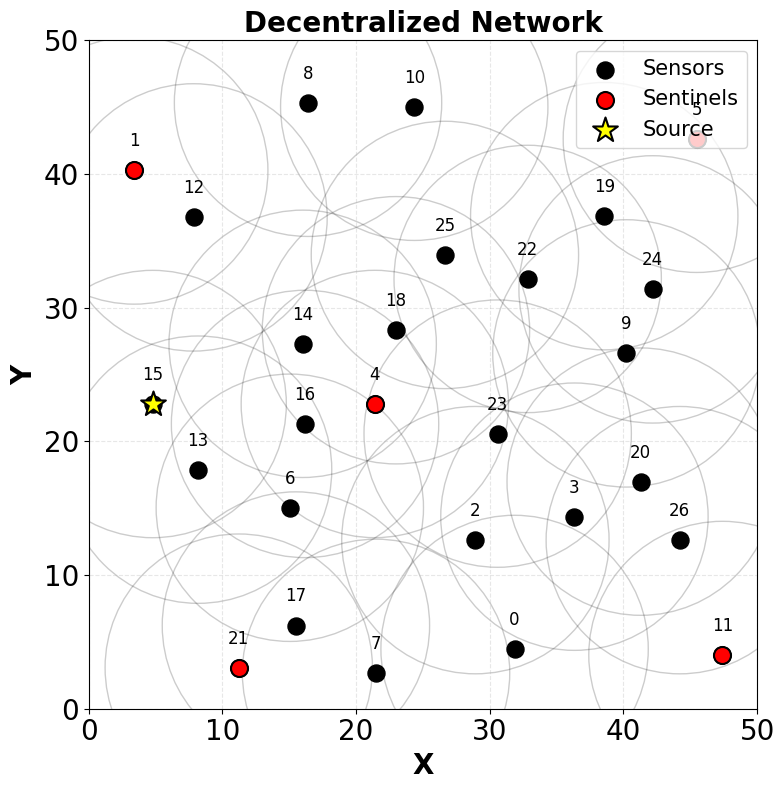

In [2]:
plot_sensor_grid_with_kernel(
    positions,
    L,
    sigma=sigma,
    r_max=r_max,
    sentinel_idx=sentinel_idx,
    source_idx=source_node,
)

In [3]:
mse_no_intervention

array([15.88345689, 18.40320282, 12.77141987,  5.2271873 ,  5.81112438,
        6.30838687,  8.94757618,  4.60912156,  2.03873784,  6.52421436,
        4.32386572,  1.70711241,  1.33584972,  1.34883295,  1.48016364,
        1.61157998,  1.25944562,  1.24090088,  1.21219302,  1.48485947,
        1.24869903,  0.99175719,  0.59419113,  0.76502468,  1.28371412,
        0.6020851 ,  0.88079032,  1.65187936,  1.64348122,  3.12603187,
        4.63658078, 14.45446714, 26.67001493, 38.71783773, 34.79772646,
       27.34881247, 20.80677145, 20.71406763, 17.3299136 , 17.21430201,
       16.21564428, 18.67608669, 18.2831408 , 18.84016249, 20.63057828,
       29.30569079, 33.68468037, 41.73605358, 35.32187533, 45.15575067,
       50.69626321, 37.35681894, 30.56117423, 36.81332652, 50.51463037,
       47.87258686, 34.30839647, 27.69181635, 32.38692767, 32.1987505 ,
       29.90963203, 39.3229049 , 29.31169931, 37.14016099, 53.5897424 ,
       51.86935194, 32.00213762, 22.72457527, 17.15807743, 16.14

In [4]:
mse_with_intervention

array([15.88345689, 18.40320282, 12.77141987,  5.2271873 ,  5.81112438,
        6.30838687,  8.94757618,  4.60912156,  2.03873784,  6.52421436,
        4.32386572,  1.70711241,  1.33584972,  1.34883295,  1.48016364,
        1.61157998,  1.25944562,  1.24090088,  1.21219302,  1.48485947,
        1.24869903,  0.99175719,  0.59419113,  0.76502468,  1.36036699,
        0.72876074,  1.23506348,  1.41282771,  1.07676041,  0.77549003,
        4.62304937, 10.91740146, 19.9651974 , 35.89005984, 30.49699222,
        0.57061017,  0.78395004,  0.66598356,  0.63114779,  0.88947922,
        0.71458154,  0.54262674,  0.47003543,  0.63486375,  0.66306796,
        0.70875082,  0.6452926 ,  2.17391448,  0.38610107,  0.40798539,
        0.37865982,  0.31292957,  0.42976165,  0.36937415,  0.27653867,
        0.31272935,  0.41861271,  0.52021983,  0.37233461,  0.31379615,
        0.26703291,  0.87253411,  0.36706736,  0.46950154,  0.26423446,
        0.26660692,  0.36563087,  0.48057425,  0.28437252,  0.37

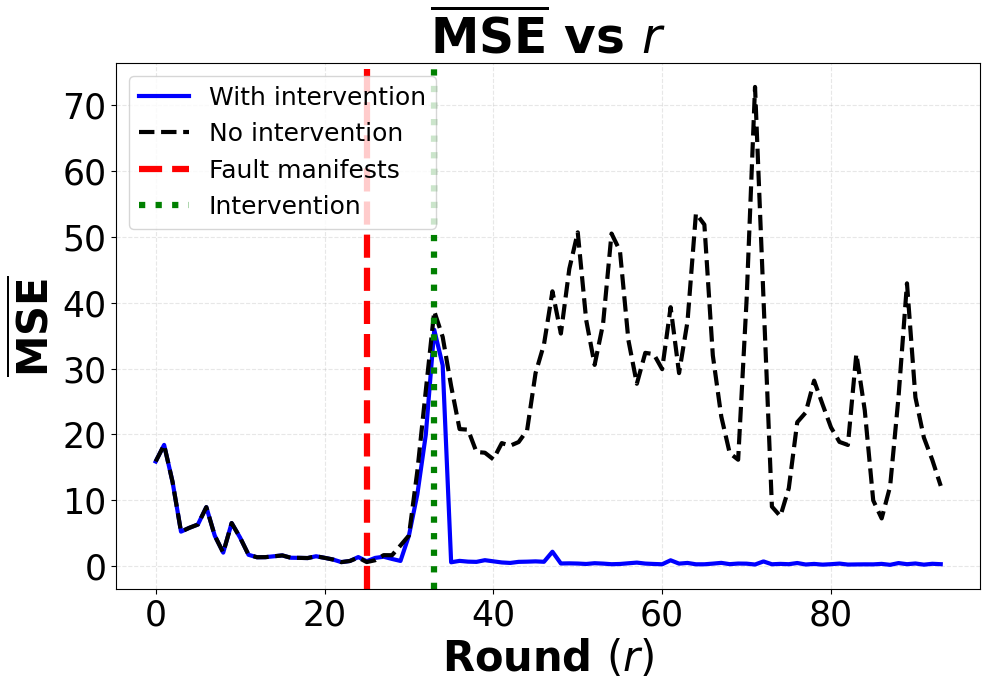

In [ ]:


plt.figure(figsize=(10, 7))
plt.plot(mse_with_intervention, '-', label="With intervention", linewidth=3, color='blue')
plt.plot(mse_no_intervention, '--', label="No intervention", linewidth=3, color='black')
plt.axvline(drift_round, color="red", linestyle="--", alpha=1, label="Fault manifests", linewidth=4.5)
plt.axvline(33, color="green", linestyle=":",
                linewidth=4.5, alpha=1, label="Intervention")
plt.xlabel(r"Round $(r)$", fontsize=30, fontweight="bold")
plt.ylabel(r"$\overline{\mathbf{MSE}}$", fontsize=30, fontweight="bold")
plt.title(r"$\overline{\mathbf{MSE}}$ vs $r$", fontsize=35, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()